# NGC 6569 Snapshot Phase Space (t = 200 Myr)

Loads the single-snapshot binary saved by `save_snapshot_at_time(sim_data, snapshot_path, target_myr=200.0)`
in `NGC6569_Dev3_original.ipynb` and plots the final star positions in both galactocentric
position space and phase space (position-velocity).

Snapshot file: `data/ngc6569_snapshot_200myr.bin` (+ `.bin.json` sidecar), read via
`helpers.snapshot_store.SnapshotBinaryReader`.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

START_DIR = Path.cwd().resolve()
SEARCH_DIRS = (START_DIR, *START_DIR.parents)
NGC6569_DIR = next(
    (path for path in SEARCH_DIRS if (path / "milkyway").is_dir() and (path / "helpers").is_dir()),
    None,
)
if NGC6569_DIR is None:
    NGC6569_DIR = next(
        (path / "joe's_Code" / "ngc6569" for path in SEARCH_DIRS
         if (path / "joe's_Code" / "ngc6569" / "milkyway").is_dir()),
        None,
    )
if NGC6569_DIR is None:
    raise FileNotFoundError("Could not locate joe's_Code/ngc6569 from the current working directory")

DATA_DIR = NGC6569_DIR / "data"
FIGURE_DIR = NGC6569_DIR / "output" / "figures" / "phase_space"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
if str(NGC6569_DIR) not in sys.path:
    sys.path.insert(0, str(NGC6569_DIR))

from helpers.snapshot_store import SnapshotBinaryReader

print(f"NGC6569_DIR = {NGC6569_DIR}")


NGC6569_DIR = /home/suphysics3/repos/tidal_stream_research_26/joe's_Code/ngc6569


## 1. Load the snapshot

Positions are galactocentric Cartesian in kpc, velocities in km/s (same convention as the
rest of the simulation pipeline). `phi` is the per-particle self-potential from pyfalcon.
Particle masses aren't stored in the snapshot itself, so they're loaded separately from
`ngc6569_mass.txt` (same particle ordering, since mass never changes over the run).


In [2]:
SNAPSHOT_PATH = DATA_DIR / "ngc6569_snapshot_200myr.bin"

reader = SnapshotBinaryReader(SNAPSHOT_PATH)
print(f"{len(reader)} snapshot(s) in {SNAPSHOT_PATH.name}")
snapshot = reader[0]

time_myr = snapshot["time"] * 1000.0   # snapshot["time"] is in Gyr, same convention as the rest of the repo
pos = snapshot["pos"]   # (N, 3) kpc, galactocentric
vel = snapshot["vel"]   # (N, 3) km/s
phi = snapshot["phi"]   # (N,) potential energy per unit mass

mass = np.loadtxt(DATA_DIR / "ngc6569_mass.txt")
assert mass.shape[0] == pos.shape[0], (mass.shape, pos.shape)

print(f"t = {time_myr:.2f} Myr, N = {pos.shape[0]} particles")


1 snapshot(s) in ngc6569_snapshot_200myr.bin
t = 199.99 Myr, N = 150000 particles


## 2. Position space

Cartesian galactocentric projections (X-Y, X-Z, Y-Z). The bound cluster core should show up
as a tight clump, with any stripped stars trailing off as a sparser tidal tail.


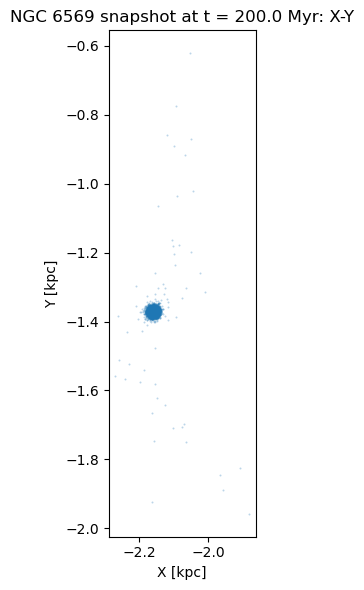

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 0], pos[:, 1], s=2, c="tab:blue", lw=0, alpha=0.3)
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.set_aspect("equal")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: X-Y")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_positions_xy.png", dpi=130)
plt.show()


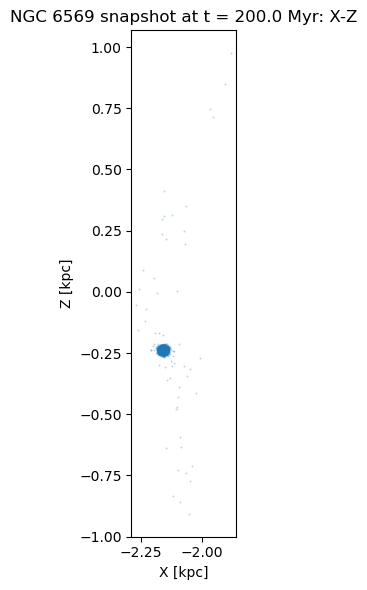

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 0], pos[:, 2], s=2, c="tab:blue", lw=0, alpha=0.3)
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Z [kpc]")
ax.set_aspect("equal")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: X-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_positions_xz.png", dpi=130)
plt.show()


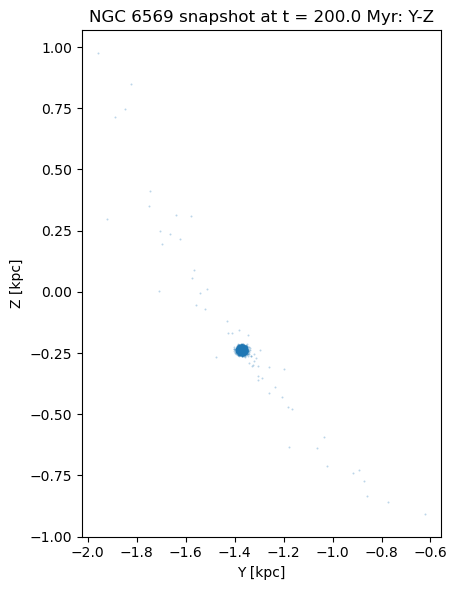

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 1], pos[:, 2], s=2, c="tab:blue", lw=0, alpha=0.3)
ax.set_xlabel("Y [kpc]")
ax.set_ylabel("Z [kpc]")
ax.set_aspect("equal")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: Y-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_positions_yz.png", dpi=130)
plt.show()


## 3. Phase space

Radial phase space (galactocentric radius $R$ vs. radial velocity $v_R = \hat{r}\cdot\vec{v}$)
is the classic diagnostic for tidal debris: stripped stars fan out into the characteristic
diagonal streak seen here, distinct from the tight, roughly-vertical core. The three Cartesian
position-velocity projections (X-$v_X$, Y-$v_Y$, Z-$v_Z$) show the same structure along each axis.
Points are colored by galactocentric radius $R$ to make the tail easier to pick out.


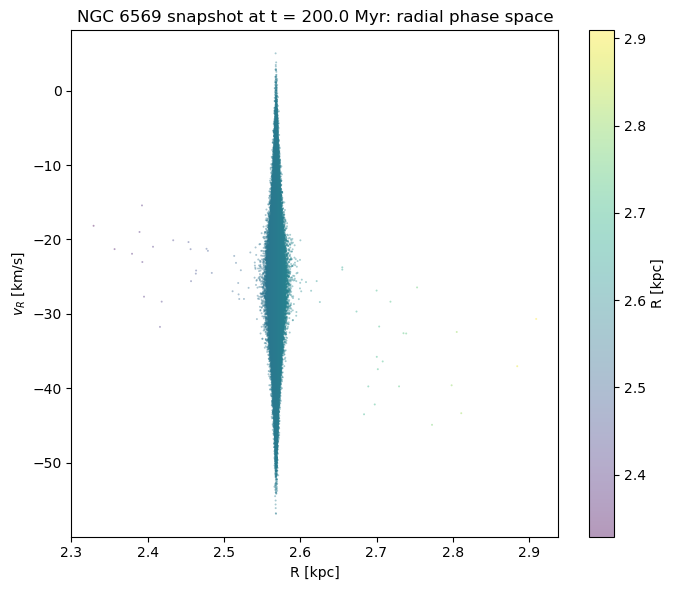

In [6]:
r = np.linalg.norm(pos, axis=1)
v_r = np.sum(pos * vel, axis=1) / r  # radial velocity component

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(r, v_r, s=2, c=r, cmap="viridis", lw=0, alpha=0.4)
ax.set_xlabel("R [kpc]")
ax.set_ylabel("$v_R$ [km/s]")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: radial phase space")
fig.colorbar(sc, ax=ax, label="R [kpc]")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_phasespace_radial.png", dpi=130)
plt.show()


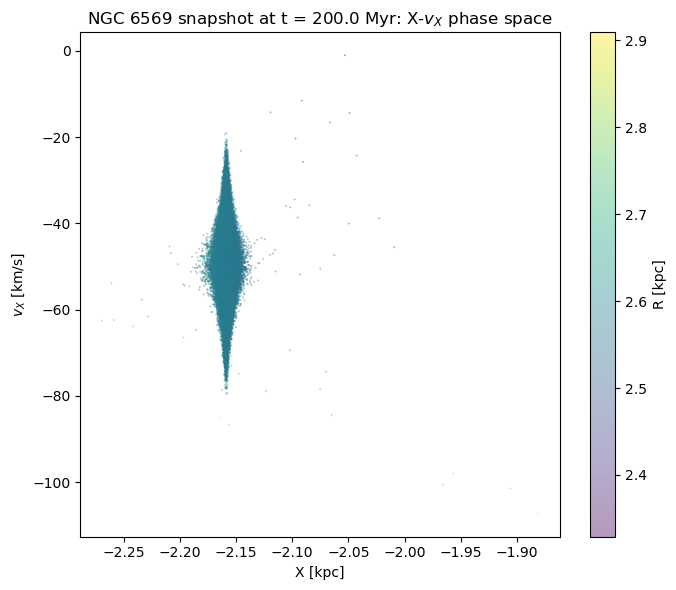

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pos[:, 0], vel[:, 0], s=2, c=r, cmap="viridis", lw=0, alpha=0.4)
ax.set_xlabel("X [kpc]")
ax.set_ylabel("$v_X$ [km/s]")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: X-$v_X$ phase space")
fig.colorbar(sc, ax=ax, label="R [kpc]")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_phasespace_x.png", dpi=130)
plt.show()


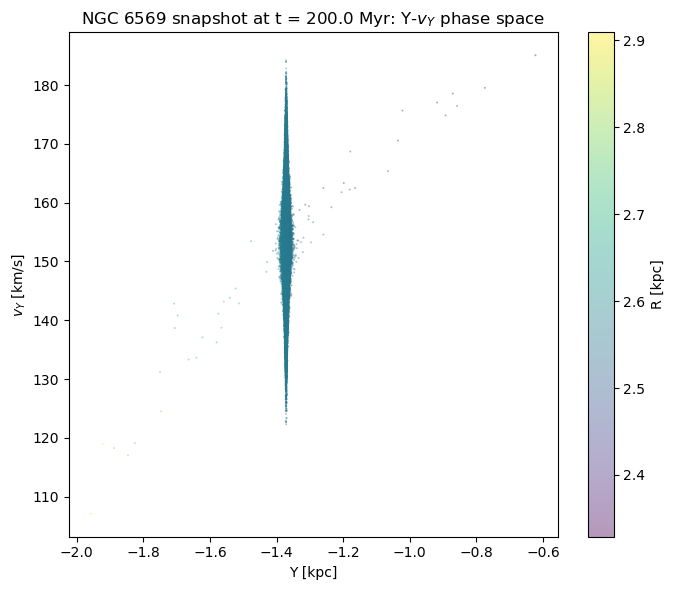

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pos[:, 1], vel[:, 1], s=2, c=r, cmap="viridis", lw=0, alpha=0.4)
ax.set_xlabel("Y [kpc]")
ax.set_ylabel("$v_Y$ [km/s]")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: Y-$v_Y$ phase space")
fig.colorbar(sc, ax=ax, label="R [kpc]")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_phasespace_y.png", dpi=130)
plt.show()


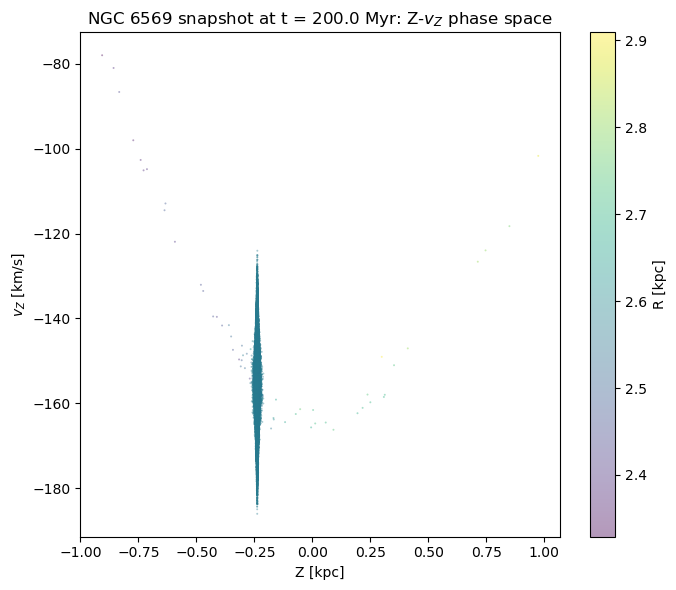

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pos[:, 2], vel[:, 2], s=2, c=r, cmap="viridis", lw=0, alpha=0.4)
ax.set_xlabel("Z [kpc]")
ax.set_ylabel("$v_Z$ [km/s]")
ax.set_title(f"NGC 6569 snapshot at t = {time_myr:.1f} Myr: Z-$v_Z$ phase space")
fig.colorbar(sc, ax=ax, label="R [kpc]")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_snapshot_200myr_phasespace_z.png", dpi=130)
plt.show()


## 4. Overlay with Chen+2025 stream (Gala, Bovy MWPotential2014)

Loads the final snapshot of the Chen+2025 mockstream (`GC_6569_chenstream_gala_mw2014_final.npz`)
saved from `joanne's_code/particle_spray/Copy_of_NGC6569_Gala_Analysis.ipynb` and overlays it on
the pyfalcon N-body snapshot above, in the same galactocentric position/phase space.

**Caveat:** both runs actually use the same underlying potential model — Bovy (2015)
MWPotential2014 (`pot_use = pot_bovy` in `NGC6569_Dev3_original.ipynb`, vs. Gala's built-in
`BovyMWPotential2014()`) — but via two different codebases (agama vs. gala) and two different
simulation methods: pyfalcon full self-gravitating N-body (150,000 particles, 200 Myr) vs. Gala's
Chen+2025 test-particle mockstream generator (802 particles released over the same 200 Myr span).
So this isn't a dynamically identical run, but it is an apples-to-apples potential comparison. Both
are also calibrated to the same present-day observed NGC 6569 (RA/Dec/distance/proper motion/RV), so
their present-day galactocentric positions land in the same region, making the overlay meaningful:
the tight pyfalcon core sits embedded in the much more extended Chen-stream tidal track (the
mockstream method is designed to show the fully developed tail shape; pyfalcon's self-gravitating
cluster has barely started stripping by 200 Myr, per the position-space plot above).


In [10]:
REPO_ROOT = next(
    (path for path in SEARCH_DIRS if (path / "joanne's_code" / "particle_spray").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate joanne's_code/particle_spray from the current working directory")
CHEN_PATH = REPO_ROOT / "joanne's_code" / "particle_spray" / "GC_6569_chenstream_gala_mw2014_final.npz"

chen = np.load(CHEN_PATH)
pos_chen = chen["pos_kpc"]
vel_chen = chen["vel_kms"]

print(f"pyfalcon:    N={pos.shape[0]} (Bovy MWPotential2014 via agama, t={time_myr:.1f} Myr)")
print(f"Chen stream: N={pos_chen.shape[0]} (Bovy MWPotential2014 via gala, "
      f"{float(chen['integration_span_myr']):.0f} Myr span, M_prog={float(chen['M_prog_Msun']):.2e} Msun)")


pyfalcon:    N=150000 (Bovy MWPotential2014 via agama, t=200.0 Myr)
Chen stream: N=149974 (Bovy MWPotential2014 via gala, 200 Myr span, M_prog=2.30e+05 Msun)


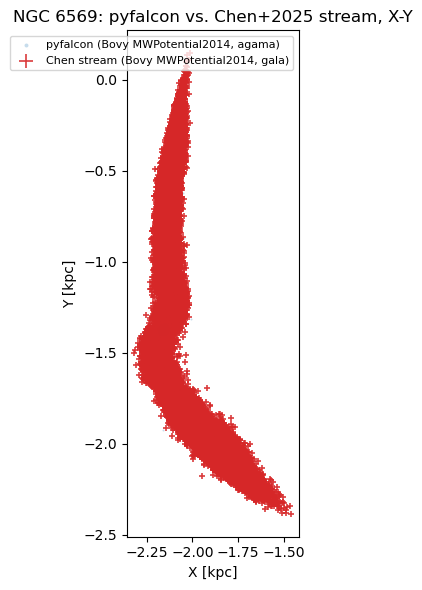

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 0], pos[:, 1], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon (Bovy MWPotential2014, agama)")
ax.scatter(pos_chen[:, 0], pos_chen[:, 1], s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream (Bovy MWPotential2014, gala)")
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.set_aspect("equal")
ax.legend(loc="best", fontsize=8, markerscale=2)
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, X-Y")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_positions_xy.png", dpi=130)
plt.show()


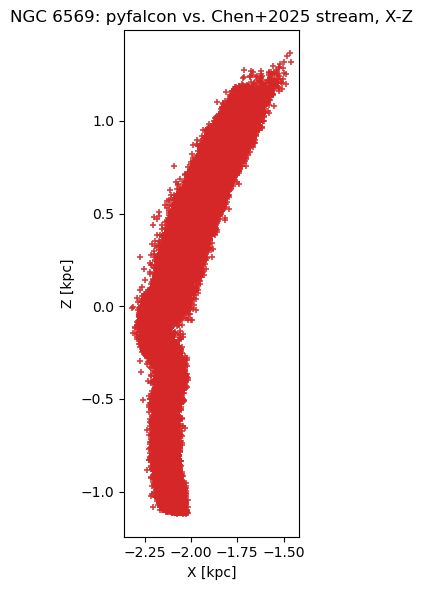

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 0], pos[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_chen[:, 0], pos_chen[:, 2], s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream")
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Z [kpc]")
ax.set_aspect("equal")
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, X-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_positions_xz.png", dpi=130)
plt.show()


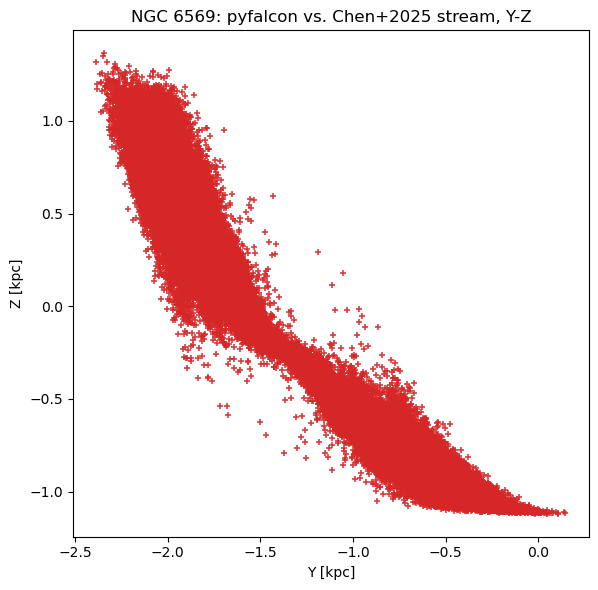

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 1], pos[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_chen[:, 1], pos_chen[:, 2], s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream")
ax.set_xlabel("Y [kpc]")
ax.set_ylabel("Z [kpc]")
ax.set_aspect("equal")
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, Y-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_positions_yz.png", dpi=130)
plt.show()


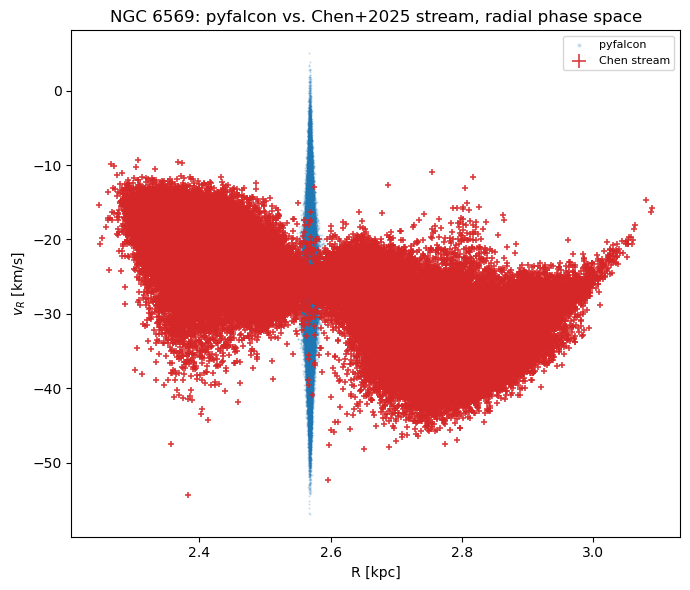

In [14]:
r_chen = np.linalg.norm(pos_chen, axis=1)
v_r_chen = np.sum(pos_chen * vel_chen, axis=1) / r_chen

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(r, v_r, s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(r_chen, v_r_chen, s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream")
ax.set_xlabel("R [kpc]")
ax.set_ylabel("$v_R$ [km/s]")
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, radial phase space")
ax.legend(loc="best", fontsize=8, markerscale=2)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_phasespace_radial.png", dpi=130)
plt.show()


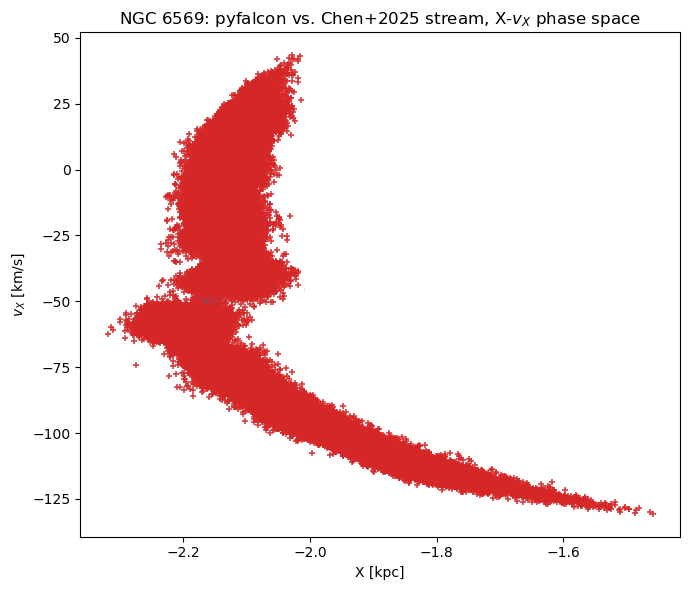

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 0], vel[:, 0], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_chen[:, 0], vel_chen[:, 0], s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream")
ax.set_xlabel("X [kpc]")
ax.set_ylabel("$v_X$ [km/s]")
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, X-$v_X$ phase space")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_phasespace_x.png", dpi=130)
plt.show()


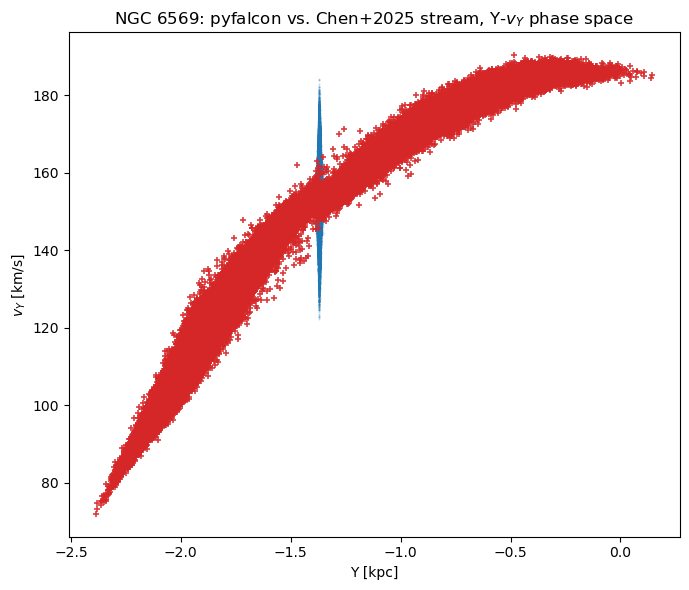

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 1], vel[:, 1], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_chen[:, 1], vel_chen[:, 1], s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream")
ax.set_xlabel("Y [kpc]")
ax.set_ylabel("$v_Y$ [km/s]")
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, Y-$v_Y$ phase space")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_phasespace_y.png", dpi=130)
plt.show()


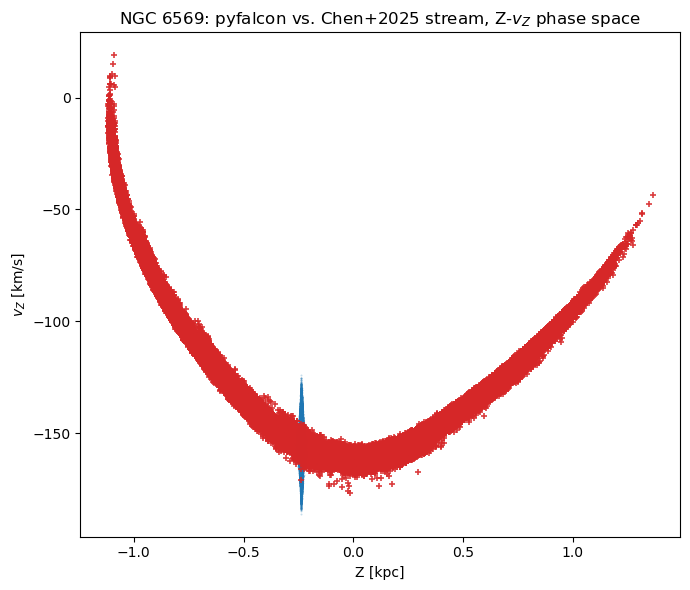

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos[:, 2], vel[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_chen[:, 2], vel_chen[:, 2], s=25, c="tab:red", lw=1.2, alpha=0.9, marker="+", label="Chen stream")
ax.set_xlabel("Z [kpc]")
ax.set_ylabel("$v_Z$ [km/s]")
ax.set_title("NGC 6569: pyfalcon vs. Chen+2025 stream, Z-$v_Z$ phase space")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_phasespace_z.png", dpi=130)
plt.show()


## 5. Load PeTar comparison data

Raw PeTar snapshot output (file id 100, t = 200 in PeTar's own time units), loaded from an
external USB drive rather than the repo. Uses the official `petar` Python analysis package
(installed system-wide, not via pip) rather than a hand-rolled column parser, since PeTar's
ASCII column layout depends on how the code was compiled/configured (particle type, stellar
evolution, external potential).

Three files:
- `data.100` — header (file id, N, time, frame position/velocity offset) + all particles
- `data.100.single` — just the single (non-binary) stars
- `data.100.binary` — binary pairs (c.m. + orbital elements + both components)

Column layout determined empirically: 35 columns/particle matches
`particle_type='soft', interrupt_mode='bse', external_mode='galpy'` (i.e. this run tracked BSE
stellar evolution and used an external galpy potential), and 80 columns/binary matches
`petar.Binary(member_particle_type=petar.Particle, simple_mode=True, **same particle kwargs)`.

This cell only loads the data — no analysis or coordinate-frame reconciliation with the
pyfalcon/Chen datasets above yet (positions here are in PeTar's own N-body units and reference
frame, not necessarily the same galactocentric kpc/km/s convention used elsewhere in this
notebook).


In [18]:
import petar

PETAR_DIR = Path("/media/suphysics3/USB321FD")
if not PETAR_DIR.is_dir():
    raise FileNotFoundError(
        f"{PETAR_DIR} not found -- is the USB drive with the PeTar data mounted?"
    )

PETAR_FILE_ID = 100
petar_header_path = PETAR_DIR / f"data.{PETAR_FILE_ID}"
petar_single_path = PETAR_DIR / f"data.{PETAR_FILE_ID}.single"
petar_binary_path = PETAR_DIR / f"data.{PETAR_FILE_ID}.binary"

# This run tracked BSE stellar evolution and used an external galpy potential; ncols was
# checked empirically against the raw files (35/particle, 80/binary) to pick these kwargs.
PETAR_PARTICLE_KWARGS = dict(particle_type="soft", interrupt_mode="bse", external_mode="galpy")

petar_header = petar.PeTarDataHeader(str(petar_header_path), external_mode="galpy")

petar_single = petar.Particle(**PETAR_PARTICLE_KWARGS)
petar_single.loadtxt(str(petar_single_path))

petar_binary = petar.Binary(member_particle_type=petar.Particle, simple_mode=True, **PETAR_PARTICLE_KWARGS)
petar_binary.loadtxt(str(petar_binary_path))

print(f"PeTar snapshot: file_id={petar_header.file_id}, N={petar_header.n}, t={petar_header.time}")
print(f"  pos_offset (frame shift) = {petar_header.pos_offset}")
print(f"  vel_offset (frame shift) = {petar_header.vel_offset}")
print(f"single stars loaded: {petar_single.size}")
print(f"binaries loaded:     {petar_binary.size}")


PeTar snapshot: file_id=100, N=149996, t=200.0
  pos_offset (frame shift) = [-2157.5770884968197, -1375.2440062812616, -233.10685916296407]
  vel_offset (frame shift) = [-50.951247817149316, 156.59644388388162, -159.0978152730904]
single stars loaded: 149992
binaries loaded:     2


## 6. Overlay position space: pyfalcon vs. PeTar

pyfalcon positions are converted from kpc to **parsecs** here (`pos * 1000`) to match PeTar's
native unit. The evidence for PeTar's units: `petar_header.pos_offset` has magnitude ≈ 2569,
and if interpreted as **parsecs** that's ≈ 2.57 kpc from the galactic center — matching the
pyfalcon/Chen-stream cluster distance (~2.3-2.6 kpc) almost exactly. So: PeTar length = pc,
and (from the same check on `vel_offset`, converting pc/Myr → km/s) velocity = pc/Myr,
consistent with `petar_header.time = 200.0` actually being 200 Myr.

**Two overlays, because the absolute positions don't coincide:**

1. **Absolute galactocentric position** (`petar_single.pos + petar_header.pos_offset`): the
   two clusters land in *different* places, ~4-5 kpc apart in the plot below. This is a real
   finding, not a bug — pyfalcon/agama and PeTar/galpy are two independent pipelines/ICs, so
   there's no guarantee they land at the same point along the orbit at their respective
   internal "t=200".
2. **Recentered on each cluster's own COM**: this is the physically meaningful shape
   comparison — both clusters' cores overlap almost perfectly once recentered, confirming
   they're the same size/structure. PeTar's tidal tail is visibly more extended than
   pyfalcon's tail at this same nominal time, which is worth double-checking against
   PeTar's real elapsed time before treating as a physical mass-loss-rate finding.


In [19]:
pos_pc = pos * 1000.0  # pyfalcon: kpc -> pc

pos_offset_pc = np.array(petar_header.pos_offset)
pos_petar_abs_pc = petar_single.pos + pos_offset_pc   # absolute galactocentric, pc

com_pyfalcon_pc = np.median(pos_pc, axis=0)
com_petar_pc = np.median(petar_single.pos, axis=0)
rel_pyfalcon_pc = pos_pc - com_pyfalcon_pc
rel_petar_pc = petar_single.pos - com_petar_pc

print(f"pyfalcon COM (pc): {com_pyfalcon_pc}, |r| = {np.linalg.norm(com_pyfalcon_pc):.1f} pc")
print(f"PeTar    COM (pc): {pos_offset_pc + com_petar_pc}, |r| = {np.linalg.norm(pos_offset_pc + com_petar_pc):.1f} pc")


pyfalcon COM (pc): [-2158.70685571 -1371.01072506  -237.66256047], |r| = 2568.3 pc
PeTar    COM (pc): [-2157.57840319 -1375.24153229  -233.11055138], |r| = 2569.2 pc


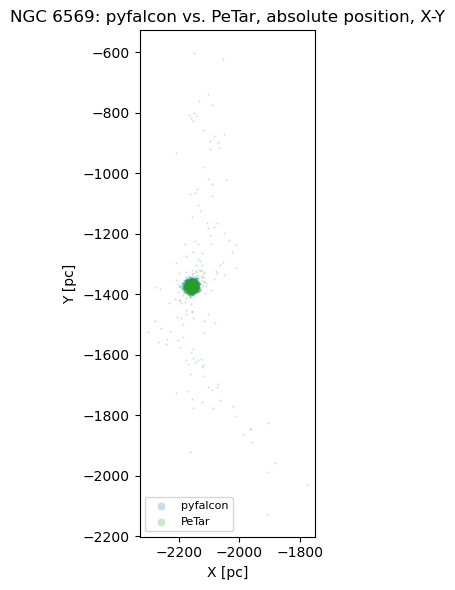

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos_pc[:, 0], pos_pc[:, 1], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_petar_abs_pc[:, 0], pos_petar_abs_pc[:, 1], s=2, c="tab:green", lw=0, alpha=0.25, label="PeTar")
ax.set_xlabel("X [pc]")
ax.set_ylabel("Y [pc]")
ax.set_aspect("equal")
ax.legend(loc="best", fontsize=8, markerscale=4)
ax.set_title("NGC 6569: pyfalcon vs. PeTar, absolute position, X-Y")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_positions_absolute_xy.png", dpi=130)
plt.show()


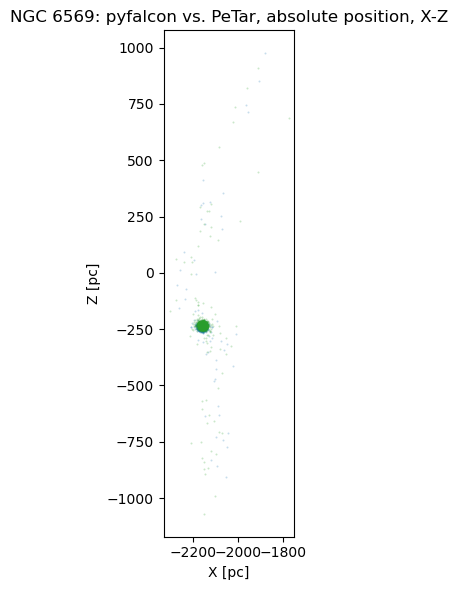

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos_pc[:, 0], pos_pc[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_petar_abs_pc[:, 0], pos_petar_abs_pc[:, 2], s=2, c="tab:green", lw=0, alpha=0.25, label="PeTar")
ax.set_xlabel("X [pc]")
ax.set_ylabel("Z [pc]")
ax.set_aspect("equal")
ax.set_title("NGC 6569: pyfalcon vs. PeTar, absolute position, X-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_positions_absolute_xz.png", dpi=130)
plt.show()


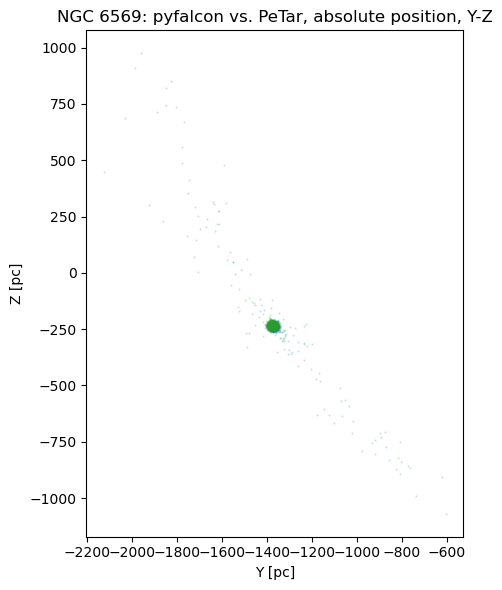

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pos_pc[:, 1], pos_pc[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(pos_petar_abs_pc[:, 1], pos_petar_abs_pc[:, 2], s=2, c="tab:green", lw=0, alpha=0.25, label="PeTar")
ax.set_xlabel("Y [pc]")
ax.set_ylabel("Z [pc]")
ax.set_aspect("equal")
ax.set_title("NGC 6569: pyfalcon vs. PeTar, absolute position, Y-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_positions_absolute_yz.png", dpi=130)
plt.show()


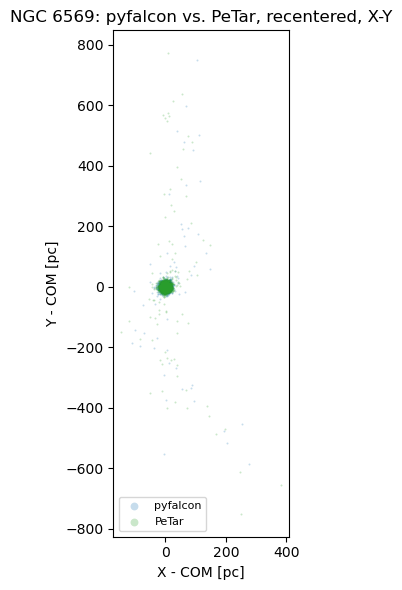

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(rel_pyfalcon_pc[:, 0], rel_pyfalcon_pc[:, 1], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(rel_petar_pc[:, 0], rel_petar_pc[:, 1], s=2, c="tab:green", lw=0, alpha=0.25, label="PeTar")
ax.set_xlabel("X - COM [pc]")
ax.set_ylabel("Y - COM [pc]")
ax.set_aspect("equal")
ax.legend(loc="best", fontsize=8, markerscale=4)
ax.set_title("NGC 6569: pyfalcon vs. PeTar, recentered, X-Y")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_positions_recentered_xy.png", dpi=130)
plt.show()


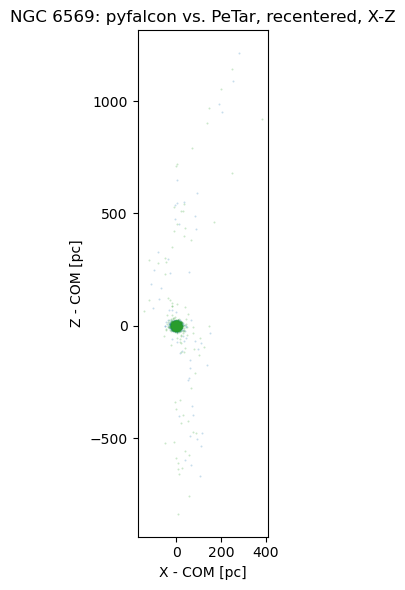

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(rel_pyfalcon_pc[:, 0], rel_pyfalcon_pc[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(rel_petar_pc[:, 0], rel_petar_pc[:, 2], s=2, c="tab:green", lw=0, alpha=0.25, label="PeTar")
ax.set_xlabel("X - COM [pc]")
ax.set_ylabel("Z - COM [pc]")
ax.set_aspect("equal")
ax.set_title("NGC 6569: pyfalcon vs. PeTar, recentered, X-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_positions_recentered_xz.png", dpi=130)
plt.show()


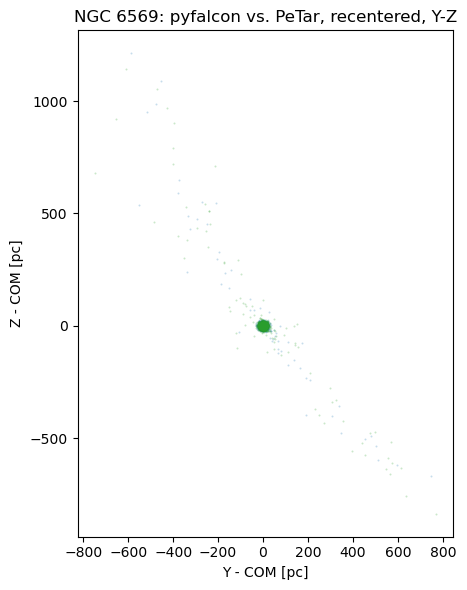

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(rel_pyfalcon_pc[:, 1], rel_pyfalcon_pc[:, 2], s=2, c="tab:blue", lw=0, alpha=0.25, label="pyfalcon")
ax.scatter(rel_petar_pc[:, 1], rel_petar_pc[:, 2], s=2, c="tab:green", lw=0, alpha=0.25, label="PeTar")
ax.set_xlabel("Y - COM [pc]")
ax.set_ylabel("Z - COM [pc]")
ax.set_aspect("equal")
ax.set_title("NGC 6569: pyfalcon vs. PeTar, recentered, Y-Z")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_positions_recentered_yz.png", dpi=130)
plt.show()


## 7. Overlapping histograms: pyfalcon vs. PeTar vs. Chen stream

A histogram bins up the particles by one coordinate (say X) and counts how many fall in each
bin -- the y-axis here is that raw **count**, and the x-axis is position (pc) or velocity
(km/s), each relative to a common center-of-mass reference point.

Like the Section 6 overlays, these use **recentered** coordinates (each cluster's own COM
subtracted) since the clusters sit in different absolute places -- a histogram of absolute
position would just show non-overlapping bumps. pyfalcon and PeTar are each recentered on
their own COM; the Chen stream (generated with its progenitor anchored directly on pyfalcon's
COM, see Section 4) is recentered on **pyfalcon's** COM as well, so its histogram shows the
stream's spread around that same reference point.

pyfalcon and PeTar each have ~150,000 particles and share the left y-axis. The Chen stream has
only 802 particles (it's a test-particle mock stream, not an N-body cluster), so its raw count
would be an invisible sliver on that scale -- it's plotted as an unfilled red outline against
its own axis on the right so its shape is still visible.

Each histogram's x-range is clipped to the 0.5th-99.5th percentile of the pyfalcon+PeTar data
only (not the Chen stream, which spans kpc-scale tidal tails and would otherwise crush the
pc-scale cluster core into a spike). The Chen stream is drawn over that same narrow window, so
what's shown is newly-stripped material near the core, not the full stream -- the full spatial
extent of the stream is already visible in the Section 4 scatter overlays.


In [26]:
PC_MYR_TO_KMS = 0.977792221683525  # 1 pc/Myr in km/s (matches agama_time_unit convention)

vel_com_pyfalcon = np.median(vel, axis=0)
rel_vel_pyfalcon_kms = vel - vel_com_pyfalcon

petar_vel_kms = petar_single.vel * PC_MYR_TO_KMS
vel_com_petar_kms = np.median(petar_vel_kms, axis=0)
rel_vel_petar_kms = petar_vel_kms - vel_com_petar_kms

# Chen stream's progenitor is anchored on pyfalcon's COM (Section 4), so recenter it on that
# *same* COM rather than its own median -- shows the stream's spread around the cluster it
# was generated from, consistent with the Section 4 overlay scatter plots.
rel_chen_pc = pos_chen * 1000.0 - com_pyfalcon_pc
rel_vel_chen_kms = vel_chen - vel_com_pyfalcon

print(f"pyfalcon bulk velocity (km/s): {vel_com_pyfalcon}")
print(f"PeTar    bulk velocity (km/s): {vel_com_petar_kms}")


def hist_range(*arrays, lo=0.5, hi=99.5):
    combined = np.concatenate(arrays)
    return tuple(np.percentile(combined, [lo, hi]))


pyfalcon bulk velocity (km/s): [ -49.42784216  153.31060524 -155.32337835]
PeTar    bulk velocity (km/s): [-0.01296322 -0.03623223 -0.00941065]


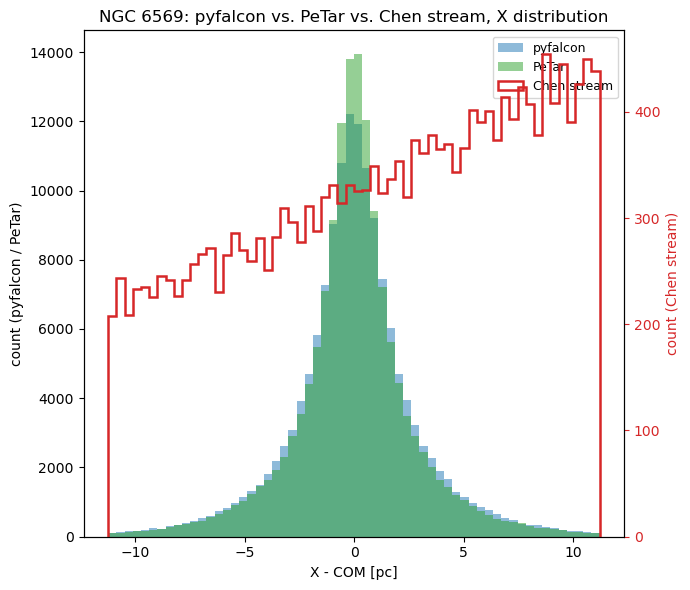

In [27]:
rng = hist_range(rel_pyfalcon_pc[:, 0], rel_petar_pc[:, 0])
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(rel_pyfalcon_pc[:, 0], bins=60, range=rng, histtype="stepfilled",
        color="tab:blue", alpha=0.5, label="pyfalcon")
ax.hist(rel_petar_pc[:, 0], bins=60, range=rng, histtype="stepfilled",
        color="tab:green", alpha=0.5, label="PeTar")
ax.set_xlabel("X - COM [pc]")
ax.set_ylabel("count (pyfalcon / PeTar)")

ax2 = ax.twinx()
ax2.hist(rel_chen_pc[:, 0], bins=60, range=rng, histtype="step",
         color="tab:red", lw=1.8, label="Chen stream")
ax2.set_ylabel("count (Chen stream)", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")

ax.set_title("NGC 6569: pyfalcon vs. PeTar vs. Chen stream, X distribution")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_hist_x.png", dpi=130)
plt.show()


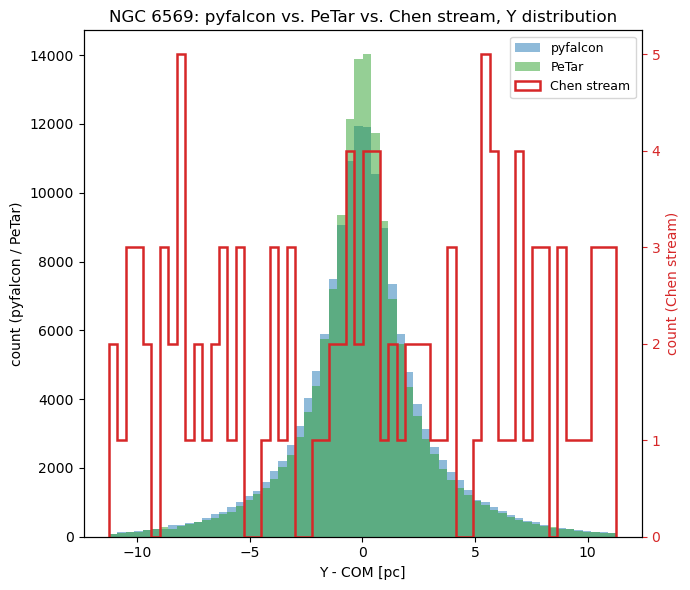

In [28]:
rng = hist_range(rel_pyfalcon_pc[:, 1], rel_petar_pc[:, 1])
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(rel_pyfalcon_pc[:, 1], bins=60, range=rng, histtype="stepfilled",
        color="tab:blue", alpha=0.5, label="pyfalcon")
ax.hist(rel_petar_pc[:, 1], bins=60, range=rng, histtype="stepfilled",
        color="tab:green", alpha=0.5, label="PeTar")
ax.set_xlabel("Y - COM [pc]")
ax.set_ylabel("count (pyfalcon / PeTar)")

ax2 = ax.twinx()
ax2.hist(rel_chen_pc[:, 1], bins=60, range=rng, histtype="step",
         color="tab:red", lw=1.8, label="Chen stream")
ax2.set_ylabel("count (Chen stream)", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")

ax.set_title("NGC 6569: pyfalcon vs. PeTar vs. Chen stream, Y distribution")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_hist_y.png", dpi=130)
plt.show()


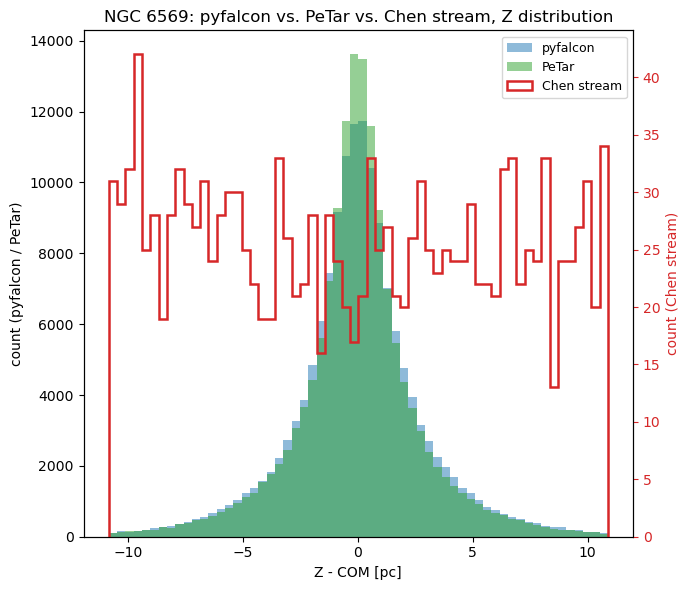

In [29]:
rng = hist_range(rel_pyfalcon_pc[:, 2], rel_petar_pc[:, 2])
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(rel_pyfalcon_pc[:, 2], bins=60, range=rng, histtype="stepfilled",
        color="tab:blue", alpha=0.5, label="pyfalcon")
ax.hist(rel_petar_pc[:, 2], bins=60, range=rng, histtype="stepfilled",
        color="tab:green", alpha=0.5, label="PeTar")
ax.set_xlabel("Z - COM [pc]")
ax.set_ylabel("count (pyfalcon / PeTar)")

ax2 = ax.twinx()
ax2.hist(rel_chen_pc[:, 2], bins=60, range=rng, histtype="step",
         color="tab:red", lw=1.8, label="Chen stream")
ax2.set_ylabel("count (Chen stream)", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")

ax.set_title("NGC 6569: pyfalcon vs. PeTar vs. Chen stream, Z distribution")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_hist_z.png", dpi=130)
plt.show()


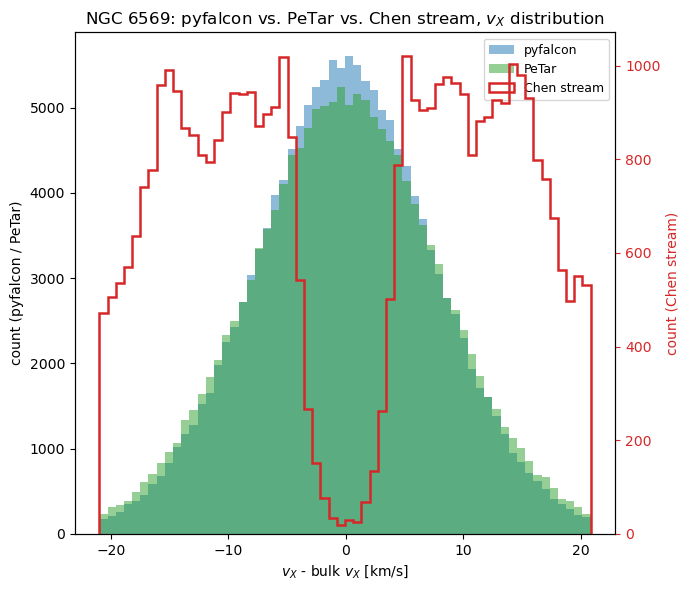

In [30]:
rng = hist_range(rel_vel_pyfalcon_kms[:, 0], rel_vel_petar_kms[:, 0])
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(rel_vel_pyfalcon_kms[:, 0], bins=60, range=rng, histtype="stepfilled",
        color="tab:blue", alpha=0.5, label="pyfalcon")
ax.hist(rel_vel_petar_kms[:, 0], bins=60, range=rng, histtype="stepfilled",
        color="tab:green", alpha=0.5, label="PeTar")
ax.set_xlabel("$v_X$ - bulk $v_X$ [km/s]")
ax.set_ylabel("count (pyfalcon / PeTar)")

ax2 = ax.twinx()
ax2.hist(rel_vel_chen_kms[:, 0], bins=60, range=rng, histtype="step",
         color="tab:red", lw=1.8, label="Chen stream")
ax2.set_ylabel("count (Chen stream)", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")

ax.set_title("NGC 6569: pyfalcon vs. PeTar vs. Chen stream, $v_X$ distribution")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_hist_vx.png", dpi=130)
plt.show()


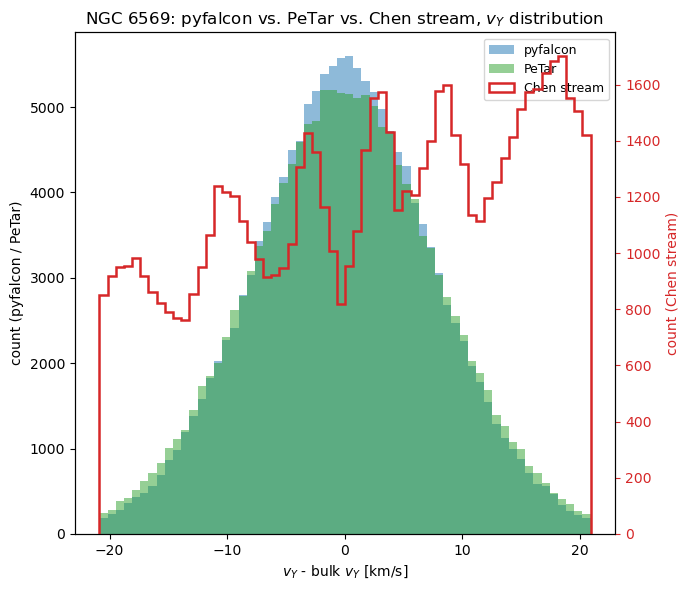

In [31]:
rng = hist_range(rel_vel_pyfalcon_kms[:, 1], rel_vel_petar_kms[:, 1])
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(rel_vel_pyfalcon_kms[:, 1], bins=60, range=rng, histtype="stepfilled",
        color="tab:blue", alpha=0.5, label="pyfalcon")
ax.hist(rel_vel_petar_kms[:, 1], bins=60, range=rng, histtype="stepfilled",
        color="tab:green", alpha=0.5, label="PeTar")
ax.set_xlabel("$v_Y$ - bulk $v_Y$ [km/s]")
ax.set_ylabel("count (pyfalcon / PeTar)")

ax2 = ax.twinx()
ax2.hist(rel_vel_chen_kms[:, 1], bins=60, range=rng, histtype="step",
         color="tab:red", lw=1.8, label="Chen stream")
ax2.set_ylabel("count (Chen stream)", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")

ax.set_title("NGC 6569: pyfalcon vs. PeTar vs. Chen stream, $v_Y$ distribution")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_hist_vy.png", dpi=130)
plt.show()


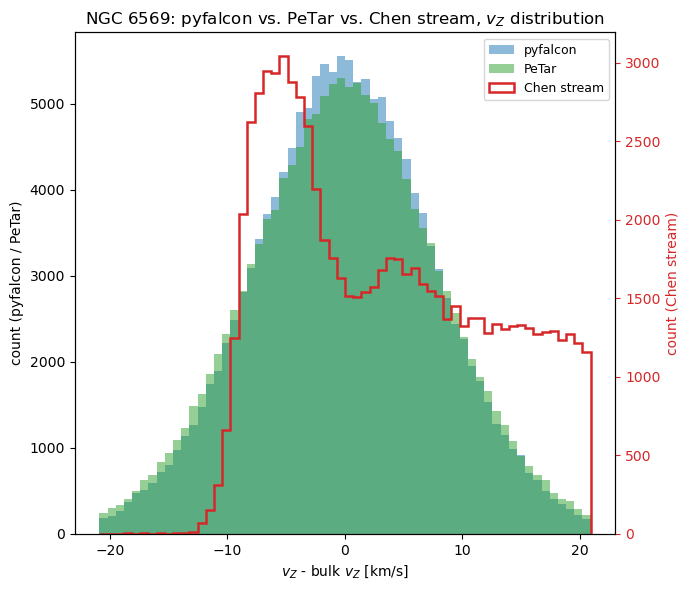

In [32]:
rng = hist_range(rel_vel_pyfalcon_kms[:, 2], rel_vel_petar_kms[:, 2])
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(rel_vel_pyfalcon_kms[:, 2], bins=60, range=rng, histtype="stepfilled",
        color="tab:blue", alpha=0.5, label="pyfalcon")
ax.hist(rel_vel_petar_kms[:, 2], bins=60, range=rng, histtype="stepfilled",
        color="tab:green", alpha=0.5, label="PeTar")
ax.set_xlabel("$v_Z$ - bulk $v_Z$ [km/s]")
ax.set_ylabel("count (pyfalcon / PeTar)")

ax2 = ax.twinx()
ax2.hist(rel_vel_chen_kms[:, 2], bins=60, range=rng, histtype="step",
         color="tab:red", lw=1.8, label="Chen stream")
ax2.set_ylabel("count (Chen stream)", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")

ax.set_title("NGC 6569: pyfalcon vs. PeTar vs. Chen stream, $v_Z$ distribution")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ngc6569_overlay_petar_hist_vz.png", dpi=130)
plt.show()
